In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings

In [12]:
warnings.filterwarnings('ignore')
np.random.seed(42)

In [13]:
values = np.random.rand(100)

labels = []
for i in values[:50]:
    if i <= 0.5:
        labels.append('Class1')
    else:
        labels.append('Class2')

labels += [None] * 50

print("Generated Labels:")
print(labels)

Generated Labels:
['Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', 'Class2', 'Class1', 'Class1', 'Class2', 'Class2', 'Class2', 'Class1', 'Class1', 'Class2', 'Class1', 'Class1', 'Class1', 'Class1', 'Class2', 'Class1', 'Class2', 'Class1', 'Class2', 'Class2', 'Class1', None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


In [14]:
data = {
    "Point": [f"x{i+1}" for i in range(100)],
    "Value": values,
    "Label": labels
}
df = pd.DataFrame(data)
df.head()

,Point,Value,Label
0,x1,0.374540,Class1
1,x2,0.950714,Class2
2,x3,0.731994,Class2
3,x4,0.598658,Class2
4,x5,0.156019,Class1


In [15]:
variable_meaning = {
    "Point": "The point number",
    "Value": "The value of the point",
    "Label": "The class of the point"
}
variable_df = pd.DataFrame(list(variable_meaning.items()), columns=["Feature", "Description"])
print("\nVariable Meaning Table:")
print(variable_df)


Variable Meaning Table:
  Feature             Description
0   Point        The point number
1   Value  The value of the point
2   Label  The class of the point


In [16]:
print("\nNumber of unique values per column:")
print(df.nunique())

print("\nShape of the dataset:")
print(df.shape)

print("\nBasic Information about Dataset:")
df.info()

print("\nSummary Statistics:")
print(df.describe().T)

print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Number of unique values per column:
Point    100
Value    100
Label      2
dtype: int64

Shape of the dataset:
(100, 3)

Basic Information about Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Point   100 non-null    object 
 1   Value   100 non-null    float64
 2   Label   50 non-null     object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB

Summary Statistics:
       count      mean       std       min       25%       50%       75%  \
Value  100.0  0.470181  0.297489  0.005522  0.193201  0.464142  0.730203   

            max  
Value  0.986887  

Missing Values in Each Column:
Point     0
Value     0
Label    50
dtype: int64


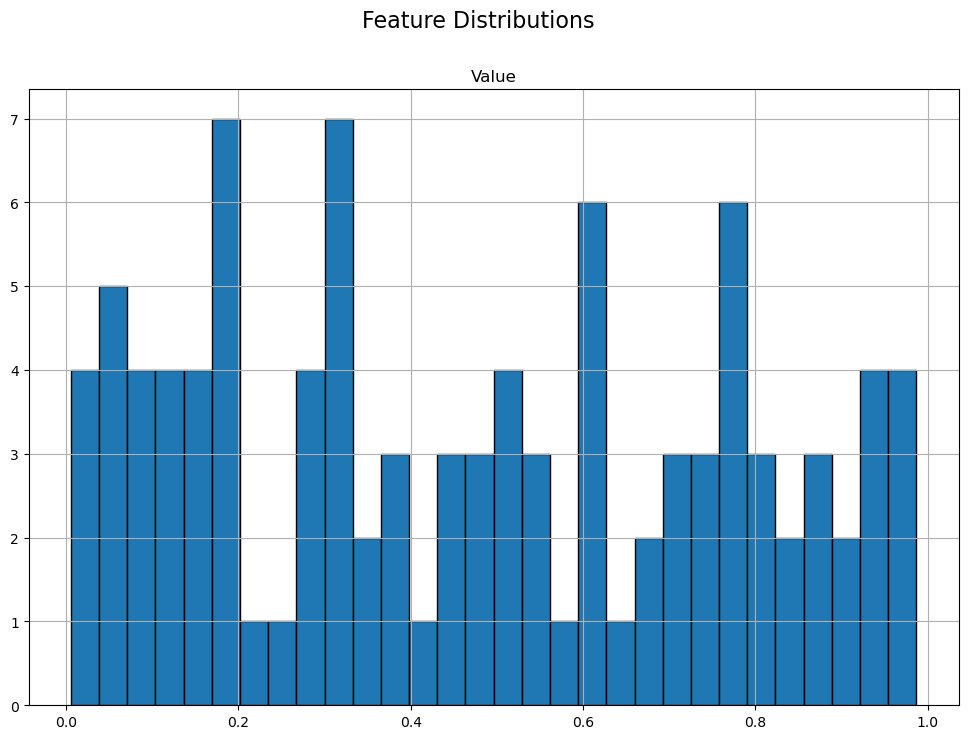

In [17]:
num_col = df.select_dtypes(include=['int', 'float']).columns
df[num_col].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [18]:
labeled_df = df[df["Label"].notna()]
X_train = labeled_df[["Value"]]
y_train = labeled_df["Label"]

unlabeled_df = df[df["Label"].isna()]
X_test = unlabeled_df[["Value"]]

In [19]:
true_labels = ["Class1" if x <= 0.5 else "Class2" for x in values[50:]]

In [20]:
k_values = [1, 2, 3, 4, 5, 20, 30]
results = {}
accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)
    results[k] = predictions
    accuracy = accuracy_score(true_labels, predictions) * 100
    accuracies[k] = accuracy
    print(f"Accuracy for k={k}: {accuracy:.2f}%")
    unlabeled_df.loc[:, f"Label_k{k}"] = predictions

Accuracy for k=1: 100.00%
Accuracy for k=2: 100.00%
Accuracy for k=3: 98.00%
Accuracy for k=4: 98.00%
Accuracy for k=5: 98.00%
Accuracy for k=20: 98.00%
Accuracy for k=30: 100.00%
